In [1]:
#user = r"\SagixOffice"
user = r"\vie43sq"
import sys
sys.path.append(rf"C:\Users{user}\OneDrive - Universität Würzburg\GitHub\Photoswitching")

import numpy as np
import src.fluorophore_systems as fs
import src.figures as fi

%load_ext autoreload
%autoreload 2

# Binned photon counts 
Intensity distributions based on different photon count bin sizes

### 1 fluorophore, S0 S1 T1 Cis R system + emccd gain

In [2]:
rate_dict = dict(k_tS0_tS1=[7e6, "excitation"],
                 k_tS1_tS0=[1e9, "emission"],
                 k_tS1_tT1=[1e6, "intersystem crossing"],
                 k_tT1_tS0=[5e5, "triplet deexcitation"],
                 
                 k_tS1_Cis=[2e7, "isomerization"],
                 k_Cis_tS0=[1e5, "backisomerization"],
                 
                 k_tT1_OFF=[1.4e6, "reduction"],
                 k_OFF_tS0=[1e0, "oxidation"])

In [3]:
system = fs.Cy5CisdSTORMModel(number=1, distances=1, rates=rate_dict)

In [4]:
system.simulate(n_steps=10000000, seed=99, base="py")

In [5]:
system.process()

## 10 µs

In [6]:
system.emitters(unit="s", resample="10us", photon_collection=0.1, emccd_gain=200)

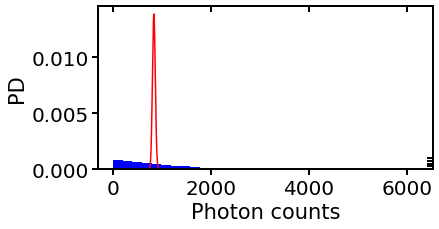

In [7]:
fig, ax = fi.FigureCollection(system).emission_events(time_series=False, bins=30, pois=True)

## 0.1 ms

In [8]:
system.emitters(unit="s", resample="0.1ms", photon_collection=0.1, emccd_gain=200)

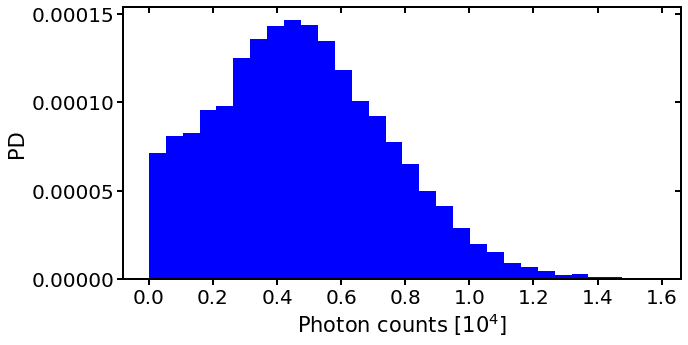

In [9]:
fig, ax = fi.FigureCollection(system).emission_events(time_series=False, bins=30,
                                                      tick_style_x="sci", 
                                                      xlabel="Photon counts [$10^4$]")

## 1 ms

In [10]:
system.emitters(unit="s", resample="1ms", photon_collection=0.1, emccd_gain=200)

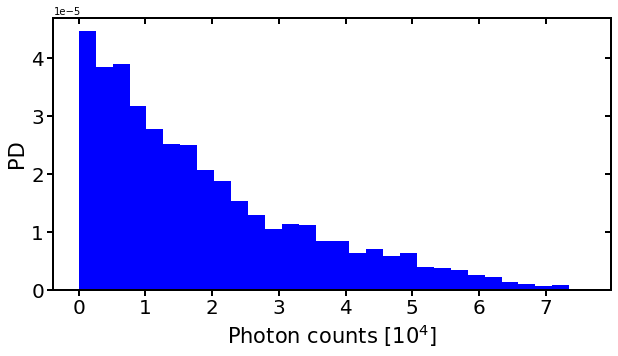

In [11]:
fig, ax = fi.FigureCollection(system).emission_events(time_series=False, bins=30,
                                                      tick_style_x="sci", 
                                                      xlabel="Photon counts [$10^4$]")

## 10 ms

In [12]:
system.emitters(unit="s", resample="10ms", photon_collection=0.1, emccd_gain=200)

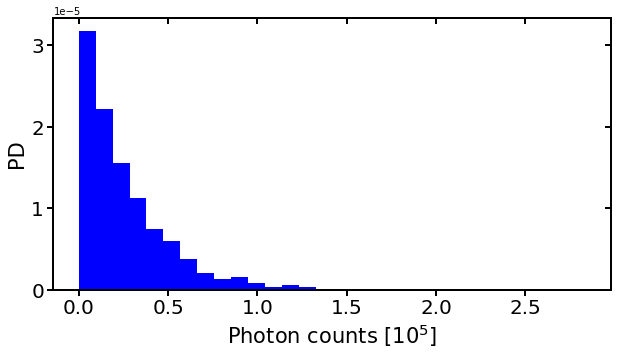

In [13]:
fig, ax = fi.FigureCollection(system).emission_events(time_series=False, bins=30,
                                                      tick_style_x="sci", 
                                                      xlabel="Photon counts [$10^5$]")